Fetch CNN Fear & Greed Index, VIX, and EPU Index for comparison against FG index

In [1]:
import os
from pathlib import Path
import pandas as pd
import requests
import yfinance as yf

START_DATE = "2022-01-01"
END_DATE = "2026-05-31"
DATA_DIR = Path(
    r"C:\Python\CSUREMM\data_primitive"
)

baseline_df = pd.read_csv(DATA_DIR / "baseline_index.csv", index_col=0)

# -------------------------------------------------------------------
# a. VIX (CBOE Volatility Index) — via Yahoo Finance
# -------------------------------------------------------------------
vix_raw = yf.download(
    "^VIX",
    start=START_DATE,
    end=END_DATE,
    progress=False
)

if isinstance(vix_raw.columns, pd.MultiIndex):
    vix = vix_raw["Close"].iloc[:, 0]
else:
    vix = vix_raw["Close"]

vix = vix.rename("VIX")
vix.index = pd.to_datetime(vix.index)

vix.to_csv(DATA_DIR / "vix.csv")

# -------------------------------------------------------------------
# b. CNN Fear & Greed Index — sourced from whit3rabbit/fear-greed-data
# -------------------------------------------------------------------
# https://github.com/whit3rabbit/fear-greed-data
# This repo maintains a canonical, auto-updated CSV combining CNN's live endpoint
# (2021-02-01 onward) with a frozen pre-2021 archive. No API key required.

FEAR_GREED_CSV_URL = "https://raw.githubusercontent.com/whit3rabbit/fear-greed-data/main/fear-greed.csv"

def fetch_fear_greed(start_date: str, end_date: str) -> pd.Series:
    fg_raw = pd.read_csv(FEAR_GREED_CSV_URL)
    fg_raw["Date"] = pd.to_datetime(fg_raw["Date"])
    fg_raw = fg_raw.set_index("Date").sort_index()

    fg = fg_raw["Fear Greed"].rename("FearGreed")
    fg = fg.loc[start_date:end_date]
    return fg

fear_greed = fetch_fear_greed(START_DATE, END_DATE)
fear_greed.head()
fear_greed.to_csv(DATA_DIR / "cnn.csv", index=True)


# -------------------------------------------------------------------
# c. US Daily Economic Policy Uncertainty (EPU) Index — policyuncertainty.com
# EPU is published as a downloadable CSV/XLS, not a REST API.
# Source: https://www.policyuncertainty.com/us_monthly.html (daily series)
# Already downloaded locally — using the file from DATA_DIR instead of a live fetch.
# -------------------------------------------------------------------

EPU_DAILY_FILE = os.path.join(DATA_DIR, "EPU_All_Daily_Policy_Data.csv")

def load_epu_daily(filepath: str, start_date: str, end_date: str) -> pd.Series:
    epu_raw = pd.read_csv(filepath)

    epu_raw["date"] = pd.to_datetime(
        epu_raw[["year", "month", "day"]]
    )

    epu = (
        epu_raw
        .set_index("date")["daily_policy_index"]
        .rename("EPU")
        .sort_index()
    )

    epu = epu.loc[start_date:end_date]
    return epu

epu = load_epu_daily(EPU_DAILY_FILE, START_DATE, END_DATE)
epu.head()
epu.to_csv(DATA_DIR / "epu.csv", index=True)

In [17]:
DATA_DIR = Path(
    r"C:\Python\CSUREMM\data_primitive"
)

baseline_df = pd.read_csv(DATA_DIR / "baseline_index.csv", index_col=0)

baseline_df.index = pd.to_datetime(baseline_df.index)

comparison_df = pd.concat(
    [baseline_df['Composite_Index'], vix, fear_greed, epu],
    axis=1
)

comparison_df = comparison_df.sort_index()
comparison_df.head()

C:\Users\20930\AppData\Local\Temp\ipykernel_32416\846354289.py:9: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  comparison_df = pd.concat(


,Composite_Index,VIX,FearGreed,EPU
2022-01-01,NaN,NaN,NaN,169.59
2022-01-02,0.329764,NaN,NaN,157.01
2022-01-03,0.410625,16.60,65.228571,146.60
2022-01-04,1.375593,16.91,64.257143,192.08
2022-01-05,1.156806,19.73,51.028571,111.08


In [18]:
comparison_df.describe()

,Composite_Index,VIX,FearGreed,EPU
count,1611.000000,1106.000000,1104.000000,1612.000000
mean,-0.435801,19.303915,48.629413,212.105962
std,0.989905,5.489685,18.947577,158.369639
min,-4.436433,11.860000,2.900000,5.390000
25%,-1.046848,15.157500,34.078571,96.615000
50%,-0.324475,17.940001,50.642857,155.900000
75%,0.300463,22.199999,64.092857,287.640000
max,1.997170,52.330002,82.971429,1048.950000


In [19]:
comparison_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1612 entries, 2022-01-01 to 2026-05-31
Freq: D
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Composite_Index  1611 non-null   float64
 1   VIX              1106 non-null   float64
 2   FearGreed        1104 non-null   float64
 3   EPU              1612 non-null   float64
dtypes: float64(4)
memory usage: 63.0 KB


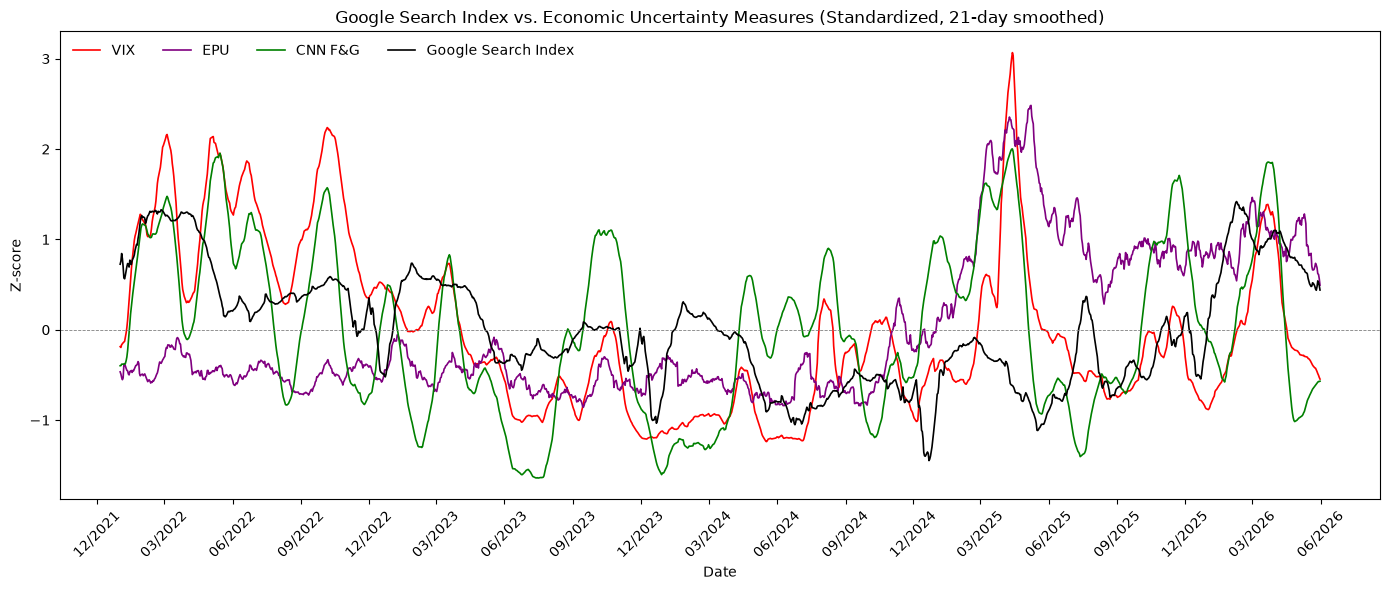

In [22]:
# -------------------------------------------------------------------
# Data cleaning / balancing before plotting
# -------------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = comparison_df.copy()

# 1. Forward-fill trading-day-only series (VIX, FearGreed) over weekends/holidays
#    so the line doesn't show gaps every Sat/Sun -- consistent with how Fig. 2
#    style charts show continuous lines despite market closures.
df["VIX"] = df["VIX"].ffill()
df["FearGreed"] = df["FearGreed"].ffill()

# EPU and Composite_Index are already fully populated daily, but ffill as a
# safety net in case of stray NaNs.
df["EPU"] = df["EPU"].ffill()
df["Composite_Index"] = df["Composite_Index"].ffill()

# 2. Drop any remaining leading NaNs (e.g. if the series starts before any
#    series has its first valid value -- bfill as a last resort for the
#    very first row(s) only)
df = df.bfill().ffill()

# 3. Re-orient FearGreed for cross-comparability (optional but recommended):
#    FearGreed is high = calm/greedy, while VIX/EPU are high = stressed.
#    Flip sign so all series move in the SAME direction (high = more fear/uncertainty),
#    matching the convention in Fig. 2 where every line rises together in crises.
df["FearGreed_inv"] = 100 - df["FearGreed"]

# 4. Z-score normalize every series so they're on a common, comparable scale.
#    Composite_Index is already a cumulative-level index built from the three
#    factors' weighted cumulative sums (from Step 1) -- no need to cumsum again here.

cols_to_plot = {
    "VIX": "VIX",
    "EPU": "EPU",
    "FearGreed_inv": "CNN F&G",
    "Composite_Index": "Google Search Index",
}

z_df = pd.DataFrame(index=df.index)
for col, label in cols_to_plot.items():
    z_df[label] = (df[col] - df[col].mean()) / df[col].std()

# Light smoothing now mainly for visual de-jaggedness, not noise removal
z_smoothed = z_df.rolling(window=21, min_periods=1, center=True).mean()

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    "VIX": "red",
    "EPU": "purple",
    "CNN F&G": "green",
    "Google Search Index": "black",
}

for label in z_smoothed.columns:
    ax.plot(
        z_smoothed.index,
        z_smoothed[label],
        label=label,
        color=colors.get(label),
        linewidth=1.2
    )

ax.set_title("Google Search Index vs. Economic Uncertainty Measures (Standardized, 21-day smoothed)")
ax.set_ylabel("Z-score")
ax.set_xlabel("Date")
ax.legend(loc="upper left", ncol=4, frameon=False)
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
cols_to_plot = {
    "VIX": "VIX",
    "EPU": "EPU",
    "FearGreed_inv": "CNN F&G",
    "Factor1_smoothed": "Google Search",
}

z_df = pd.DataFrame(index=df.index)
for col, label in cols_to_plot.items():
    z_df[label] = (df[col] - df[col].mean()) / df[col].std()

z_smoothed = z_df.rolling(window=21, min_periods=1, center=True).mean()